### Build a DNN using Keras with `RELU` and `ADAM`

#### Load tensorflow

In [0]:
import os
import tensorflow as tf
import collections, numpy as np

#### Collect Fashion mnist data from tf.keras.datasets 

In [12]:
from keras.datasets import fashion_mnist
(x_train, y_train), (x_test, y_test) = fashion_mnist.load_data()

print( x_train.shape)
print( x_test.shape)

(60000, 28, 28)
(10000, 28, 28)


#### Change train and test labels into one-hot vectors

In [13]:
#check the unique values of y_train and y_test before converting to 1 hot vectors 
np.unique(y_train, axis=0)

array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9], dtype=uint8)

In [14]:
np.unique(y_test, axis=0)

array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9], dtype=uint8)

In [0]:
#convert output to one hot encoded data
y_train = tf.keras.utils.to_categorical(y_train, num_classes=10)
y_test = tf.keras.utils.to_categorical(y_test, num_classes=10)

#### Build the Graph

image label: 0


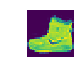

image label: 1


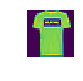

image label: 1


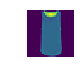

image label: 0


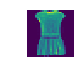

image label: 1


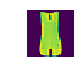

image label: 0


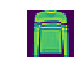

image label: 0


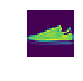

image label: 0


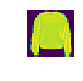

image label: 0


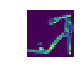

image label: 0


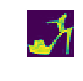

image label: 1


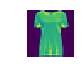

image label: 0


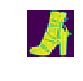

image label: 0


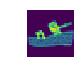

image label: 0


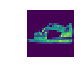

image label: 0


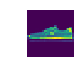

image label: 0


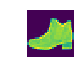

image label: 0


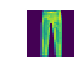

image label: 1


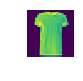

image label: 0


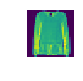

image label: 0


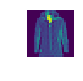

image label: 0


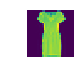

image label: 0


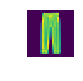

image label: 0


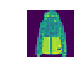

image label: 0


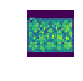

image label: 0


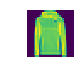

In [22]:
#Plot first 25 images in the dataset 
%matplotlib inline
import matplotlib.pyplot as plt

for i in range(25):
    plt.figure(figsize=(25, 1))
    plt.subplot(1, 25, i+1)
    plt.imshow(x_train[i].reshape(28, 28))
    plt.axis('off')
    print('image label: %s' % (np.argmax(y_train[0:25][i])))
    plt.show()

#### Initialize model, reshape & normalize data

In [0]:
x_train = x_train.astype('float32')
x_test = x_test.astype('float32')

x_train /= 255
x_test /= 255


In [0]:
x_train = x_train.reshape(x_train.shape[0], 28, 28, 1)
x_test = x_test.reshape(x_test.shape[0], 28, 28, 1)
input_shape = (28, 28, 1)

#### Add two fully connected layers with 200 and 100 neurons respectively with `relu` activations. Add a dropout layer with `p=0.25`

In [0]:
# Importing the required Keras modules containing model and layers
from keras.models import Sequential
from keras.layers import Dense, Conv2D, Dropout, Flatten, MaxPooling2D
from keras import regularizers
from keras import optimizers


import keras
import keras.utils
from keras import utils as np_utils

In [26]:
# Creating a Sequential Model and adding the layers
model1 = Sequential()
model1.add(Conv2D(32, kernel_size=(3,3), input_shape=input_shape, activation = 'relu'))
model1.add(keras.layers.MaxPool2D(pool_size=(2,2)))
model1.add(Dropout(0.25))
model1.add(Flatten()) # Flattening the 2D arrays for fully connected layers
model1.add(Dense(200, activation="relu"))
model1.add(Dense(100, activation="relu"))



W0825 17:19:28.743803 140169739646848 deprecation_wrapper.py:119] From /usr/local/lib/python3.6/dist-packages/keras/backend/tensorflow_backend.py:74: The name tf.get_default_graph is deprecated. Please use tf.compat.v1.get_default_graph instead.

W0825 17:19:28.783713 140169739646848 deprecation_wrapper.py:119] From /usr/local/lib/python3.6/dist-packages/keras/backend/tensorflow_backend.py:517: The name tf.placeholder is deprecated. Please use tf.compat.v1.placeholder instead.

W0825 17:19:28.792638 140169739646848 deprecation_wrapper.py:119] From /usr/local/lib/python3.6/dist-packages/keras/backend/tensorflow_backend.py:4138: The name tf.random_uniform is deprecated. Please use tf.random.uniform instead.

W0825 17:19:28.835302 140169739646848 deprecation_wrapper.py:119] From /usr/local/lib/python3.6/dist-packages/keras/backend/tensorflow_backend.py:3976: The name tf.nn.max_pool is deprecated. Please use tf.nn.max_pool2d instead.

W0825 17:19:28.839098 140169739646848 deprecation_wrapp

### Add the output layer with a fully connected layer with 10 neurons with `softmax` activation. Use `categorical_crossentropy` loss and `adam` optimizer and train the network. And, report the final validation.

In [27]:
model1.add(Dense(10, activation="softmax"))


model1.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])


model1.fit(x_train, y_train,
          epochs=10,
          batch_size=64
          )

W0825 17:19:29.678942 140169739646848 deprecation_wrapper.py:119] From /usr/local/lib/python3.6/dist-packages/keras/optimizers.py:790: The name tf.train.Optimizer is deprecated. Please use tf.compat.v1.train.Optimizer instead.

W0825 17:19:29.708307 140169739646848 deprecation_wrapper.py:119] From /usr/local/lib/python3.6/dist-packages/keras/backend/tensorflow_backend.py:3295: The name tf.log is deprecated. Please use tf.math.log instead.



ValueError: ignored

In [28]:
model1.summary()

model1.evaluate(x_test, y_test)

_________________________________________________________________
Layer (type)                 Output Shape              Param #   
conv2d_1 (Conv2D)            (None, 26, 26, 32)        320       
_________________________________________________________________
max_pooling2d_1 (MaxPooling2 (None, 13, 13, 32)        0         
_________________________________________________________________
dropout_1 (Dropout)          (None, 13, 13, 32)        0         
_________________________________________________________________
flatten_1 (Flatten)          (None, 5408)              0         
_________________________________________________________________
dense_1 (Dense)              (None, 200)               1081800   
_________________________________________________________________
dense_2 (Dense)              (None, 100)               20100     
_________________________________________________________________
dense_3 (Dense)              (None, 10)                1010      
Total para

ValueError: ignored

In [0]:
#score on train data
score = model.evaluate(x_train, y_train, verbose=0)
score
print("The accuracy of train data is: ",score[1])